# q337 K-Sweep Validation

This notebook validates the first three sanity checks for `dalg-cache/pile_wikipedia_gemma2b_mfa_100k/q337_k_sweep`:

1. Re-evaluate saved models on the exact held-out split with strict validation precision.
2. Compare train NLL and validation NLL for the same checkpoints.
3. Verify every K uses the same validation rows and compatible run config.

The cells are intentionally direct and easy to edit. The default checked K values are `[10, 100, 1000]`.

In [1]:
from pathlib import Path
import gc
import hashlib
import json
import sys

import pandas as pd
import torch
from torch.utils.data import DataLoader

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from dalg.data.shard_activations import ActivationBatchDataset, load_meta_index, stratified_split
from dalg.data.subset_spec import resolve_spec_positions
from dalg.models.mfa import load_mfa
from dalg.models.train import _strict_validation_matmul

SWEEP_ROOT = REPO_ROOT / "dalg-cache/pile_wikipedia_gemma2b_mfa_100k/q337_k_sweep"
RESULTS_PATH = SWEEP_ROOT / "results.json"
LAYER = 17
RANK = 337
SUBSET_SPEC = "pile_wikipedia_100K"
K_CHECK = [10, 100, 1000]
BATCH_SIZE = 2048

assert SWEEP_ROOT.exists(), SWEEP_ROOT
print(SWEEP_ROOT)

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/pile_wikipedia_gemma2b_mfa_100k/q337_k_sweep


## Shared Split Reconstruction

Reconstruct the same Wikipedia 100K-token slice and train/validation split used by the sweep. This is used by all following sections.

In [2]:
reference_run = SWEEP_ROOT / f"layer{LAYER:02d}_{K_CHECK[0]}_{RANK}_mfa"
run_cfg = json.loads((reference_run / "config.json").read_text())

ACTIVATION_DIR = REPO_ROOT / run_cfg["shard_dir"]
WINDOW = int(run_cfg["window"])
DROP_PREFIX = int(run_cfg["drop_prefix"])
VAL_FRAC = float(run_cfg["val_frac"])
SPLIT_SEED = int(run_cfg["split_seed"])

meta_index = load_meta_index(ACTIVATION_DIR, LAYER)
slice_positions = resolve_spec_positions(
    meta_index,
    SUBSET_SPEC,
    window=WINDOW,
    drop_prefix=DROP_PREFIX,
)
train_positions, val_positions = stratified_split(
    meta_index,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    positions=slice_positions,
)
val_global_rows = [int(meta_index[p]["global_row"]) for p in val_positions]

tokens_per_row = WINDOW - DROP_PREFIX
print({
    "activation_dir": str(ACTIVATION_DIR),
    "subset_spec": SUBSET_SPEC,
    "slice_rows": len(slice_positions),
    "train_rows": len(train_positions),
    "val_rows": len(val_positions),
    "tokens_per_row": tokens_per_row,
    "train_tokens": len(train_positions) * tokens_per_row,
    "val_tokens": len(val_positions) * tokens_per_row,
})

{'activation_dir': '/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/pile_gemma2b_activations', 'subset_spec': 'pile_wikipedia_100K', 'slice_rows': 447, 'train_rows': 402, 'val_rows': 45, 'tokens_per_row': 224, 'train_tokens': 90048, 'val_tokens': 10080}


In [3]:
def run_dir_for_k(k: int) -> Path:
    return SWEEP_ROOT / f"layer{LAYER:02d}_{int(k)}_{RANK}_mfa"


def token_loader(row_positions, *, batch_size=BATCH_SIZE):
    ds = ActivationBatchDataset(
        ACTIVATION_DIR,
        LAYER,
        row_subset=row_positions,
        batch_size=batch_size,
        drop_prefix=DROP_PREFIX,
        dtype=torch.float32,
        return_metadata=False,
        shuffle_shards=False,
        shuffle_within_shard=False,
        seed=0,
    )
    return DataLoader(ds, batch_size=None, num_workers=0), ds.num_items


@torch.no_grad()
def eval_nll(model, row_positions, *, device, batch_size=BATCH_SIZE):
    loader, n_items = token_loader(row_positions, batch_size=batch_size)
    model.eval()
    total = 0.0
    total_n = 0
    with _strict_validation_matmul(device):
        for batch in loader:
            x = batch[0] if isinstance(batch, (tuple, list)) else batch
            x = x.view(x.size(0), -1).to(device).float()
            loss = model.nll(x)
            total += float(loss.item()) * x.size(0)
            total_n += x.size(0)
    assert total_n == n_items, (total_n, n_items)
    return total / max(total_n, 1)


def load_best_metric(k: int):
    ckpt = torch.load(run_dir_for_k(k) / "checkpoint.pt", map_location="cpu", weights_only=False)
    return float(ckpt["best_metric"]), int(ckpt.get("best_epoch", -1)), int(ckpt.get("epoch", -1))


def clear_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 1. Re-evaluate Saved Models With Strict Precision

This recomputes held-out NLL for selected saved `mfa_model.pt` checkpoints. On CUDA it uses `_strict_validation_matmul`, which disables TF32 and sets matmul precision to `highest`. The recomputed values should match `checkpoint.pt['best_metric']` up to small numerical drift.

CPU for `K=1000, q=337` can be slow. Set `DEVICES = ['cuda']` if you only want the strict CUDA check.

In [4]:
DEVICES = ["cpu"] + (["cuda"] if torch.cuda.is_available() else [])
# DEVICES = ["cuda"]

rows = []
for k in K_CHECK:
    ckpt_best, best_epoch, final_epoch = load_best_metric(k)
    model_path = run_dir_for_k(k) / "mfa_model.pt"
    for device_name in DEVICES:
        device = torch.device(device_name)
        print(f"K={k} device={device} loading {model_path}")
        model = load_mfa(model_path, map_location="cpu").to(device)
        val_nll = eval_nll(model, val_positions, device=device)
        rows.append({
            "K": k,
            "device": device_name,
            "checkpoint_best_metric": ckpt_best,
            "recomputed_val_nll": val_nll,
            "delta_vs_checkpoint": val_nll - ckpt_best,
            "best_epoch": best_epoch,
            "final_epoch": final_epoch,
        })
        clear_model(model)

strict_eval_df = pd.DataFrame(rows)
display(strict_eval_df)

K=10 device=cpu loading /orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/pile_wikipedia_gemma2b_mfa_100k/q337_k_sweep/layer17_10_337_mfa/mfa_model.pt
K=10 device=cuda loading /orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/pile_wikipedia_gemma2b_mfa_100k/q337_k_sweep/layer17_10_337_mfa/mfa_model.pt
K=100 device=cpu loading /orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/pile_wikipedia_gemma2b_mfa_100k/q337_k_sweep/layer17_100_337_mfa/mfa_model.pt
K=100 device=cuda loading /orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/pile_wikipedia_gemma2b_mfa_100k/q337_k_sweep/layer17_100_337_mfa/mfa_model.pt
K=1000 device=cpu loading /orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/pile_wikipedia_gemma2b_mfa_100k/q337_k_sweep/layer17_1000_337_mfa/mfa_model.pt
K=1000 device=cuda loading /orfeo/cephfs/home/dssc/zenocosin

,K,device,checkpoint_best_metric,recomputed_val_nll,delta_vs_checkpoint,best_epoch,final_epoch
0,10,cpu,6220.999050,6222.744672,1.745623,554,574
1,10,cuda,6220.999050,6222.744683,1.745633,554,574
2,100,cpu,9780.187339,9786.279948,6.092609,186,206
3,100,cuda,9780.187339,9786.280339,6.093000,186,206
4,1000,cpu,23633.149188,23635.505903,2.356715,24,44
5,1000,cuda,23633.149188,23635.505469,2.356281,24,44


## 2. Compare Train NLL And Validation NLL

If train NLL improves or stays reasonable while validation NLL increases with K, the plot is a generalization/overfitting result, not a contradiction of expressivity. If train NLL also gets worse with K, then optimization or initialization is likely dominating.

K=10 device=cuda train/val evaluation
K=100 device=cuda train/val evaluation
K=1000 device=cuda train/val evaluation


,K,device,train_nll,val_nll,val_minus_train,checkpoint_best_metric,best_epoch,final_epoch
0,10,cuda,5777.525030,6222.744683,445.219654,6220.999050,554,574
1,100,cuda,6216.827086,9786.280339,3569.453253,9780.187339,186,206
2,1000,cuda,9763.689564,23635.505469,13871.815905,23633.149188,24,44


Text(0.5, 1.0, 'Layer 17, q=337: train vs validation NLL')

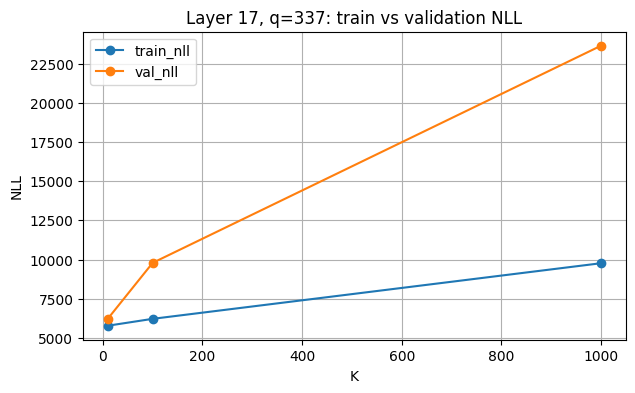

In [5]:
DEVICE_FOR_TRAIN_VAL = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rows = []
for k in K_CHECK:
    ckpt_best, best_epoch, final_epoch = load_best_metric(k)
    model_path = run_dir_for_k(k) / "mfa_model.pt"
    print(f"K={k} device={DEVICE_FOR_TRAIN_VAL} train/val evaluation")
    model = load_mfa(model_path, map_location="cpu").to(DEVICE_FOR_TRAIN_VAL)
    train_nll = eval_nll(model, train_positions, device=DEVICE_FOR_TRAIN_VAL)
    val_nll = eval_nll(model, val_positions, device=DEVICE_FOR_TRAIN_VAL)
    rows.append({
        "K": k,
        "device": str(DEVICE_FOR_TRAIN_VAL),
        "train_nll": train_nll,
        "val_nll": val_nll,
        "val_minus_train": val_nll - train_nll,
        "checkpoint_best_metric": ckpt_best,
        "best_epoch": best_epoch,
        "final_epoch": final_epoch,
    })
    clear_model(model)

train_val_df = pd.DataFrame(rows)
display(train_val_df)
ax = train_val_df.plot(x="K", y=["train_nll", "val_nll"], marker="o", figsize=(7, 4), grid=True)
ax.set_ylabel("NLL")
ax.set_title(f"Layer {LAYER}, q={RANK}: train vs validation NLL")

## 3. Verify The Same Validation Rows Across K

This checks every layer-17 q337 run folder in the sweep root, not only `K_CHECK`. It compares each saved `val_indices.json` against the split reconstructed above, and also checks key config fields that must be identical for fair comparison.

In [6]:
def hash_int_list(values):
    payload = ",".join(str(int(v)) for v in values).encode()
    return hashlib.sha256(payload).hexdigest()[:16]


expected_val_hash = hash_int_list(val_global_rows)
expected_fields = {
    "rank": RANK,
    "layer": LAYER,
    "shard_dir": run_cfg["shard_dir"],
    "window": WINDOW,
    "drop_prefix": DROP_PREFIX,
    "val_frac": VAL_FRAC,
    "split_seed": SPLIT_SEED,
    "training_mode": "vanilla",
}

rows = []
for run_dir in sorted(SWEEP_ROOT.glob(f"layer{LAYER:02d}_*_{RANK}_mfa")):
    try:
        k = int(run_dir.name.split("_")[1])
    except (IndexError, ValueError):
        continue
    cfg = json.loads((run_dir / "config.json").read_text())
    saved = json.loads((run_dir / "val_indices.json").read_text())
    saved_val_rows = [int(x) for x in saved["val_global_rows"]]
    cfg_mismatches = {
        key: {"expected": value, "actual": cfg.get(key)}
        for key, value in expected_fields.items()
        if cfg.get(key) != value
    }
    rows.append({
        "K": k,
        "run_dir": run_dir.name,
        "val_rows": len(saved_val_rows),
        "val_hash": hash_int_list(saved_val_rows),
        "matches_recomputed_split": saved_val_rows == val_global_rows,
        "matches_reference_hash": hash_int_list(saved_val_rows) == expected_val_hash,
        "train_rows_recorded": saved.get("train_rows"),
        "val_rows_recorded": saved.get("val_rows"),
        "cfg_mismatches": cfg_mismatches,
    })

split_df = pd.DataFrame(rows).sort_values("K")
display(split_df)
print("expected_val_hash", expected_val_hash)
print("all rows match recomputed split:", bool(split_df["matches_recomputed_split"].all()))
print("all configs compatible:", bool(split_df["cfg_mismatches"].map(lambda x: len(x) == 0).all()))

,K,run_dir,val_rows,val_hash,matches_recomputed_split,matches_reference_hash,train_rows_recorded,val_rows_recorded,cfg_mismatches
2,10,layer17_10_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}
5,25,layer17_25_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}
7,50,layer17_50_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}
9,75,layer17_75_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}
1,100,layer17_100_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}
3,150,layer17_150_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}
4,200,layer17_200_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}
6,400,layer17_400_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}
8,600,layer17_600_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}
10,800,layer17_800_337_mfa,45,86ff1acbdcc46bed,True,True,402,45,{}


expected_val_hash 86ff1acbdcc46bed
all rows match recomputed split: True
all configs compatible: True
